<a href="https://colab.research.google.com/github/ZaramNelo/Predictive-ER-Admission-Engine/blob/main/notebooks/04_pytorch_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 · PyTorch model vs the nurse's ESI score

**Question:** using only triage-time information, can a model predict who gets admitted better than the nurse's ESI score alone?

Steps: load → split → prepare → build model → train → evaluate vs ESI → chart.

In [1]:
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, precision_score

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_parquet("/content/drive/MyDrive/prae/triage_subset.parquet")
df.shape

Mounted at /content/drive


(560486, 215)

## 1. Inputs, answer, and split
`y` = was the patient admitted (1) or discharged (0). `X` = everything known at triage.
70% train / 15% validation / 15% test. Validation is used to pick cutoffs; test is only for the final scores. `stratify` keeps the ~30% admit rate the same in every split.

In [2]:
y = (df["disposition"] == "Admit").astype(int)
X = df.drop(columns=["disposition"])

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)
print(len(X_tr), len(X_va), len(X_te))

392340 84073 84073


## 2. Prepare numbers for the network
- Text columns → 0/1 columns (`get_dummies`)
- Flag where vitals were missing, then fill gaps with the training median
- Standardize (subtract training mean, divide by training std) so every column is on a similar scale

All statistics come from the **training rows only**, so nothing leaks from validation/test.

In [3]:
missing = X.filter(like="triage_vital_").isna().astype("float32").add_suffix("_missing")
X_num = pd.concat([pd.get_dummies(X, dtype="float32"), missing], axis=1)
X_num = X_num.fillna(X_num.loc[X_tr.index].median())
mu, sd = X_num.loc[X_tr.index].mean(), X_num.loc[X_tr.index].std() + 1e-6
X_num = ((X_num - mu) / sd).fillna(0)

to_tensor = lambda idx: torch.tensor(X_num.loc[idx].values, dtype=torch.float32)
Xt_tr, Xt_va, Xt_te = to_tensor(X_tr.index), to_tensor(X_va.index), to_tensor(X_te.index)
yt_tr = torch.tensor(y_tr.values, dtype=torch.float32)
yt_va = torch.tensor(y_va.values, dtype=torch.float32)
Xt_tr.shape

torch.Size([392340, 248])

## 3. Build the model
A small neural network: inputs → 64 neurons (ReLU) → 1 raw score.
- `BCEWithLogitsLoss`: loss for yes/no problems; applies the sigmoid internally (raw score → probability).
- `Adam`: optimizer that adapts the step size per weight.

In [4]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(Xt_tr.shape[1], 64), nn.ReLU(),
    nn.Linear(64, 1),
)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 4. Train
Each batch: forward pass → loss → zero gradients → backpropagation → optimizer step.
We print the loss and AUROC on the **whole validation set** each epoch (a last-batch loss is too noisy to trust).

In [5]:
for epoch in range(5):
    order = torch.randperm(len(Xt_tr))
    for i in range(0, len(order), 1024):
        idx = order[i:i+1024]
        pred = model(Xt_tr[idx]).squeeze(1)       # forward pass
        loss = loss_fn(pred, yt_tr[idx])          # calculate loss
        optimizer.zero_grad()                     # zero the gradients
        loss.backward()                           # backpropagation
        optimizer.step()                          # optimizer step
    with torch.no_grad():
        logits_va = model(Xt_va).squeeze(1)
        val_loss = loss_fn(logits_va, yt_va).item()
        risk_va = torch.sigmoid(logits_va).numpy()
    print(f"epoch {epoch}: validation loss={val_loss:.4f}  validation AUROC={roc_auc_score(y_va, risk_va):.3f}")

epoch 0: validation loss=0.4007  validation AUROC=0.872
epoch 1: validation loss=0.3969  validation AUROC=0.874
epoch 2: validation loss=0.3959  validation AUROC=0.875
epoch 3: validation loss=0.3949  validation AUROC=0.876
epoch 4: validation loss=0.3947  validation AUROC=0.876


## 5. Predict on the test set
`risk` = predicted probability of admission for each test patient (0 to 1).

In [6]:
with torch.no_grad():
    risk = torch.sigmoid(model(Xt_te).squeeze(1)).numpy()
print("Test AUROC:", round(roc_auc_score(y_te, risk), 3))

Test AUROC: 0.878


## 6. Model vs the nurse's ESI
**AUROC:** chance a random admitted patient gets a higher score than a random non-admitted one (0.5 = coin flip, 1.0 = perfect).

ESI is turned into a score by giving each ESI level its historical admit rate (from training data).

**Recall** = share of real admits we flag. **Precision** = share of flagged patients who were really admitted. To compare fairly we match recall and compare false alarms.

In [7]:
yv, yt = y_va.values, y_te.values
esi = X_te["esi"].values

# ESI as a risk score: each level -> its admit rate in the training set
rate = y_tr.groupby(X_tr["esi"]).mean()
fallback = y_tr.mean()   # for any patient with a missing ESI
esi_va = X_va["esi"].map(rate).fillna(fallback).values
esi_te = X_te["esi"].map(rate).fillna(fallback).values

print("Nurse ESI AUROC:", round(roc_auc_score(yt, esi_te), 3))
print("My model AUROC: ", round(roc_auc_score(yt, risk), 3))

# Model alone at 90% recall (cutoff chosen on validation)
cut90 = np.quantile(risk_va[yv == 1], 0.10)
flag90 = risk >= cut90
print("\nModel @90% recall -> recall:", round(recall_score(yt, flag90), 3),
      "| precision:", round(precision_score(yt, flag90), 3))

# Nurse rule (ESI <= 3) vs model at the SAME recall
nurse_flag = esi <= 3
target = recall_score(yv, X_va["esi"].values <= 3)
model_flag = risk >= np.quantile(risk_va[yv == 1], 1 - target)
print()
for name, flag in [("Nurse (ESI <= 3)", nurse_flag), ("Model, same recall", model_flag)]:
    print(f"{name}: flagged {int(flag.sum()):,} | recall {recall_score(yt, flag):.3f} "
          f"| precision {precision_score(yt, flag):.3f} | false alarms {int((flag & (yt == 0)).sum()):,}")

Nurse ESI AUROC: 0.765
My model AUROC:  0.878

Model @90% recall -> recall: 0.9 | precision: 0.533

Nurse (ESI <= 3): flagged 60,692 | recall 0.979 | precision 0.403 | false alarms 36,225
Model, same recall: flagged 57,522 | recall 0.979 | precision 0.425 | false alarms 33,063


## 7. Chart
Grey = what really happened, orange = the nurse rule (ESI 1–3 = admit, 4–5 = not), blue = the model's average predicted risk. The nurse rule is all-or-nothing; the model gives a graded risk.

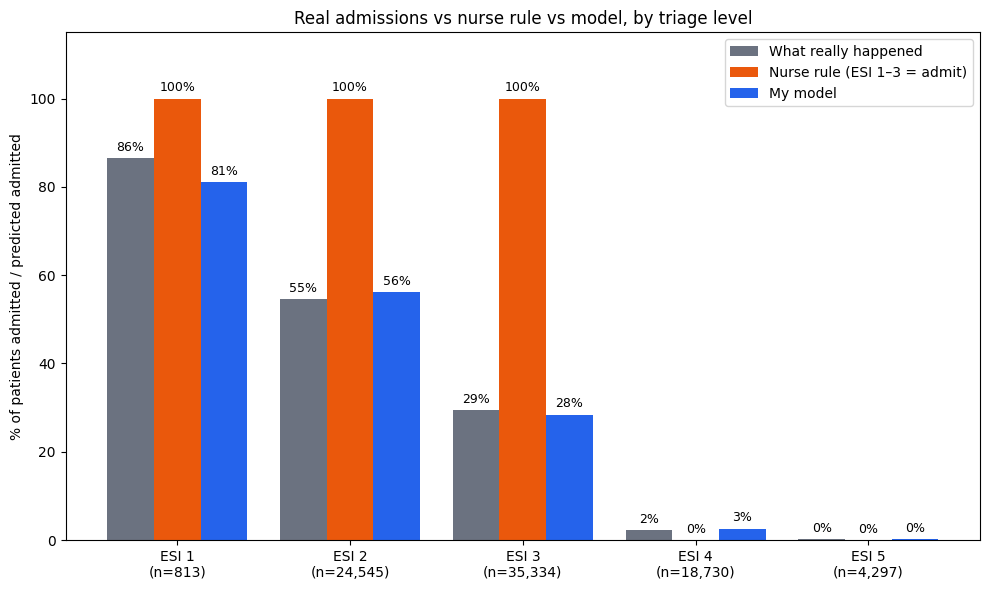

In [8]:
levels = [1, 2, 3, 4, 5]
actual = [100 * yt[esi == k].mean() for k in levels]
model_ = [100 * risk[esi == k].mean() for k in levels]
nurse_ = [100 if k <= 3 else 0 for k in levels]

x, w = np.arange(len(levels)), 0.27
fig, ax = plt.subplots(figsize=(10, 6))
bars = [ax.bar(x - w, actual, w, color="#6B7280", label="What really happened"),
        ax.bar(x,     nurse_, w, color="#EA580C", label="Nurse rule (ESI 1–3 = admit)"),
        ax.bar(x + w, model_, w, color="#2563EB", label="My model")]
for b in bars:
    ax.bar_label(b, fmt="%.0f%%", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"ESI {k}\n(n={int((esi == k).sum()):,})" for k in levels])
ax.set_ylabel("% of patients admitted / predicted admitted")
ax.set_ylim(0, 115)
ax.set_title("Real admissions vs nurse rule vs model, by triage level")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("real_vs_nurse_vs_model.png", dpi=150)
plt.show()

## Results

| Method | Test AUROC |
|---|---|
| Nurse ESI (as a score) | 0.766 |
| Logistic regression | 0.872 |
| **PyTorch (this notebook)** | **0.878** |
| LightGBM | 0.880 |

- At 90% recall the model's precision is 0.533.
- At the same recall as the ESI ≤ 3 rule (97.9%) the model raises about 3,200 fewer false alarms (33,063 vs 36,225, ~9% fewer).
- The model's main advantage over ESI is a continuous risk score instead of a coarse 5-level scale.

**Takeaway:** triage-only data caps AUROC around 0.88 for both a small neural net and LightGBM. Gains beyond that need more pre-arrival information (e.g. chief complaint, history), not a bigger model.